In [1]:
import os
import sys
import logging
import random
import numpy as np

# Keep Kaggle output readable while TensorFlow initializes.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.FATAL)

import tensorflow as tf

# Fixed seeds make the comparison as reproducible as practical.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# -----------------------------------------------------------------------------
# REPOSITORY CONFIGURATION
# -----------------------------------------------------------------------------
REPO_NAME = "RefraScan"
GITHUB_USER = "KyziaPi"
BRANCH_NAME = "Model-Experiment"  # Change to the branch containing the finalized VSCode code.
REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"
REPO_PATH = os.path.join("/kaggle/working", REPO_NAME)

if not os.path.exists(REPO_PATH):
    !env GIT_TERMINAL_PROMPT=0 git clone -b {BRANCH_NAME} {REPO_URL}
else:
    !cd {REPO_PATH} && env GIT_TERMINAL_PROMPT=0 git fetch --all && git checkout {BRANCH_NAME} && git pull origin {BRANCH_NAME}

if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

import sys
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

from src.preprocessing import load_and_clean_data, encode_target, validate_dataset
from src.cross_validation import (
    split_holdout_test,
    run_cross_validation,
    train_final_on_development,
    evaluate_holdout_once,
)
from src.models import build_model

Cloning into 'RefraScan'...
remote: Enumerating objects: 572, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 572 (delta 144), reused 129 (delta 60), pack-reused 344 (from 1)
Receiving objects: 100% (572/572), 50.56 MiB | 26.51 MiB/s, done.
Resolving deltas: 100% (318/318), done.


In [3]:
# -----------------------------------------------------------------------------
# FINAL EXPERIMENT CONFIGURATION
# -----------------------------------------------------------------------------
# Set this ONLY after comparing EfficientNetB3, ResNet50, and DenseNet121
# using their image-only 10-fold CV results.
BEST_MODEL_NAME = "resnet50"  # Change after the controlled comparison.

PREPROCESS_INPUT = {
    "efficientnet": efficientnet_preprocess,
    "resnet50": resnet_preprocess,
    "densenet121": densenet_preprocess,
}[BEST_MODEL_NAME]

DATASET_DIR = '/kaggle/input/datasets/yerikaelainegueco/fundus-images-with-refractive-values'
CSV_PATH = os.path.join(DATASET_DIR, 'RefraScan_dataset.csv')
IMG_DIR = os.path.join(DATASET_DIR, 'FundusImages')

df = load_and_clean_data(CSV_PATH, IMG_DIR)

print("Dataset columns:")
print(df.columns.tolist())
print("\nData origin distribution:")
print(df["data_origin"].value_counts())

df = validate_dataset(df, patient_col="ID", target_col="classification")
df = encode_target(df)

# Recreate the fixed 15% holdout using the same random seed.
development_df, holdout_df = split_holdout_test(
    df, patient_col="ID", target_col="classification_encoded", test_size=0.15
)

print("\nHoldout data origins:")
print(holdout_df["data_origin"].value_counts())

print(f"Selected architecture: {BEST_MODEL_NAME}")

Dataset columns:
['ID', 'sphere', 'cylinder', 'spherical_equivalent', 'age', 'classification', 'eye_side', 'data_origin', 'full_path']

Data origin distribution:
data_origin
AUFMC - Lasik    560
PAPILA           458
Name: count, dtype: int64

DATASET VALIDATION

Total records       : 1,018
Unique patients     : 517
Missing patient IDs : 0
Missing labels      : 0
Duplicate rows      : 0

Class distribution:
classification
Myopia        660
Hyperopia     236
Emmetropia    122
Name: count, dtype: int64

Patients with multiple target classes: 50
These patients have different classifications between their eyes. This is allowed.

Example mixed-class patients:
 ID classification
  2     Emmetropia
  2         Myopia
  4     Emmetropia
  4      Hyperopia
  7     Emmetropia
  7         Myopia
 14         Myopia
 14     Emmetropia
 19     Emmetropia
 19      Hyperopia
 24      Hyperopia
 24     Emmetropia
 27     Emmetropia
 27         Myopia
 34     Emmetropia
 34      Hyperopia
 42     Emmetro

In [4]:
# Testing Cell
# -----------------------------------------------------------------------------
# PROGRESSIVE FINE-TUNING OF THE SELECTED IMAGE-ONLY ARCHITECTURE
# -----------------------------------------------------------------------------
# DEBUG RUN: 2 folds only.
# Stage 1: unfreeze the upper 10 non-BatchNorm layers.
# Stage 2: expand to the upper 30 non-BatchNorm layers.
# Both stages use the same folds and a low learning rate of 1e-5.

fine_tuned_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=2,  # DEBUG ONLY — restore to 10 for the final experiment
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=False,
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/fine_tuning_debug",
    fine_tune=True,
    fine_tune_epochs=10,
    fine_tune_learning_rate=1e-5,
    fine_tune_stages=[10, 30],
)

fine_tuned_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/final_image_only_finetuned_cv_results_debug.csv",
    index=False,
)


PATIENT-LEVEL HOLDOUT SPLIT
Development records : 864
Holdout records     : 154
Development patients: 439
Holdout patients    : 78
Patient overlap     : 0

The holdout set is now untouched and will not be used for architecture/model selection.

RESNET50 | IMAGE ONLY
2-FOLD STRATIFIED GROUP CROSS-VALIDATION

--- Fold 1/2 ---


I0000 00:00:1786982105.040863      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786982105.043670      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/30
 2/27 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.3750 - loss: 0.9784 

I0000 00:00:1786982127.028888     143 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.4850 - loss: 0.9258
Epoch 1: val_loss improved from None to 0.36449, saving model to /kaggle/working/RefraScan/artifacts/fine_tuning_debug/resnet50_image_fold_1_frozen.keras

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/fine_tuning_debug/resnet50_image_fold_1_frozen.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5563 - loss: 0.8288 - val_accuracy: 0.7489 - val_loss: 0.3645
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.5493 - loss: 0.6484
Epoch 2: val_loss improved from 0.36449 to 0.33167, saving model to /kaggle/working/RefraScan/artifacts/fine_tuning_debug/resnet50_image_fold_1_frozen.keras

Epoch 2: finished saving model to /kaggle/working/RefraScan/artifacts/fine_tuning_debug/resnet50_image_fold_1_frozen.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 709ms/step - accuracy: 0.5563 - loss: 0.5533 - val_accuracy: 0.7352 - val_loss: 0.3317
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/

In [ ]:
# -----------------------------------------------------------------------------
# PROGRESSIVE FINE-TUNING OF THE SELECTED IMAGE-ONLY ARCHITECTURE
# -----------------------------------------------------------------------------
# Stage 1: unfreeze the upper 10 non-BatchNorm layers.
# Stage 2: expand to the upper 30 non-BatchNorm layers.
# Both stages use the same folds and a low learning rate of 1e-5.

fine_tuned_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=10,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=False,
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/fine_tuning",
    fine_tune=True,
    fine_tune_epochs=10,
    fine_tune_learning_rate=1e-5,
    fine_tune_stages=[10, 30],
)

fine_tuned_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/final_image_only_finetuned_cv_results.csv",
    index=False,
)

In [5]:
# Testing Cell
# -----------------------------------------------------------------------------
# ABLATION: FUNDUS IMAGE ONLY VS FUNDUS IMAGE + AGE
# -----------------------------------------------------------------------------
# DEBUG RUN: 2 folds only.
# Age is the ONLY additional feature tested here.
# Sphere, cylinder, and spherical equivalent remain excluded because they
# determine the refractive-error target.

age_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=2,  # DEBUG ONLY — restore to 10 for final experiment
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=True,
    metadata_cols=["age_scaled"],
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/age_ablation_debug",
    fine_tune=False,
)

age_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/image_plus_age_cv_results_debug.csv",
    index=False,
)

print(
    "\nDEBUG RUN: Compare the Macro F1 and balanced accuracy means "
    "to verify the pipeline completes correctly."
)


PATIENT-LEVEL HOLDOUT SPLIT
Development records : 864
Holdout records     : 154
Development patients: 439
Holdout patients    : 78
Patient overlap     : 0

The holdout set is now untouched and will not be used for architecture/model selection.

RESNET50 | IMAGE + AGE
2-FOLD STRATIFIED GROUP CROSS-VALIDATION

--- Fold 1/2 ---
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.4482 - loss: 1.4289
Epoch 1: val_loss improved from None to 0.36392, saving model to /kaggle/working/RefraScan/artifacts/age_ablation_debug/resnet50_age_fold_1_frozen.keras

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/age_ablation_debug/resnet50_age_fold_1_frozen.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.4460 - loss: 1.0195 - val_accuracy: 0.7329 - val_loss: 0.3639
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.5854 - loss: 0.6143
Epoch 2: val_loss improved from 0.36392 to 0.34321, saving model to /kaggle/working/RefraScan/artifacts/age_a

In [ ]:
# -----------------------------------------------------------------------------
# ABLATION: FUNDUS IMAGE ONLY VS FUNDUS IMAGE + AGE
# -----------------------------------------------------------------------------
# Age is the ONLY additional feature tested here.
# Sphere, cylinder, and spherical equivalent remain excluded because they
# determine the refractive-error target.

age_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=10,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=True,
    metadata_cols=["age_scaled"],
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/age_ablation",
    fine_tune=False,
)

age_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/image_plus_age_cv_results.csv",
    index=False,
)

print("\nCompare the Macro F1 and balanced accuracy means above before choosing the final configuration.")

In [6]:
# -----------------------------------------------------------------------------
# FINAL TRAINING ON ALL 85% DEVELOPMENT DATA
# -----------------------------------------------------------------------------
# At this point the architecture and feature configuration have already been
# selected using development-data CV. The 15% holdout remains untouched.

USE_AGE = False  # Set True only if the image+age ablation is the selected final configuration.
METADATA_COLS = ["age_scaled"] if USE_AGE else None

final_model, final_history = train_final_on_development(
    development_df=development_df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=USE_AGE,
    metadata_cols=METADATA_COLS,
    output_path=f"/kaggle/working/{REPO_NAME}/artifacts/final_model.keras",
    fine_tune=True,
    fine_tune_layers=30,
    fine_tune_epochs=10,
    fine_tune_learning_rate=1e-5,
    fine_tune_stages=[10, 30],
)

print("Final model trained using development data only.")

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.4884 - loss: 0.8387
Epoch 1: saving model to /kaggle/working/RefraScan/artifacts/final_model.keras

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 348ms/step - accuracy: 0.5579 - loss: 0.6492
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.6285 - loss: 0.4779
Epoch 2: saving model to /kaggle/working/RefraScan/artifacts/final_model.keras

Epoch 2: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 340ms/step - accuracy: 0.6331 - loss: 0.4705
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.6499 - loss: 0.4254
Epoch 3: saving model to /kaggle/working/RefraScan/artifacts/final_model.keras

Epoch 3: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 335ms/step - accuracy: 0.6678 - loss: 0.4193
Epoch 4/30

In [7]:
# -----------------------------------------------------------------------------
# FINAL HOLDOUT EVALUATION -- RUN THIS CELL ONCE
# -----------------------------------------------------------------------------
# Do NOT rerun this evaluation to make additional architecture/hyperparameter
# decisions. The holdout is the final unbiased estimate.
if USE_AGE:
    import joblib
    age_scaler = joblib.load(
        f"/kaggle/working/{REPO_NAME}/artifacts/final_model_age_scaler.joblib"
    )
    holdout_df["age_scaled"] = age_scaler.transform(holdout_df[["age"]])

final_holdout_result = evaluate_holdout_once(
    model=final_model,
    holdout_df=holdout_df,
    preprocess_input=PREPROCESS_INPUT,
    batch_size=16,
    use_metadata=USE_AGE,
    metadata_cols=METADATA_COLS,
    model_name=BEST_MODEL_NAME,
)


--- Running Inference ---

--- Classification Report ---
              precision    recall  f1-score   support

  Emmetropia       0.37      0.26      0.30        27
      Myopia       0.83      0.78      0.81        88
   Hyperopia       0.52      0.69      0.59        39

    accuracy                           0.67       154
   macro avg       0.57      0.58      0.57       154
weighted avg       0.67      0.67      0.66       154

--- Evaluation Metrics ---
Accuracy          : 0.6688
Balanced Accuracy : 0.5786
Macro Precision   : 0.5730
Macro Recall      : 0.5786
Macro F1          : 0.5683

Confusion Matrix:
[[ 7  4 16]
 [10 69  9]
 [ 2 10 27]]

*** FINAL HOLDOUT EVALUATION COMPLETED ONCE ***


Grad-CAM layer: conv5_block3_out


PAPILA vs AUF-MC PREDICTION RESULTS
prediction_status  Correct  Incorrect
image_source                         
AUF-MC                  67          9
PAPILA                  39         39
PAPILA: 39/78 correct (50.00%)
AUF-MC: 67/76 correct (88.16%)


GRAD-CAM EXAMPLES


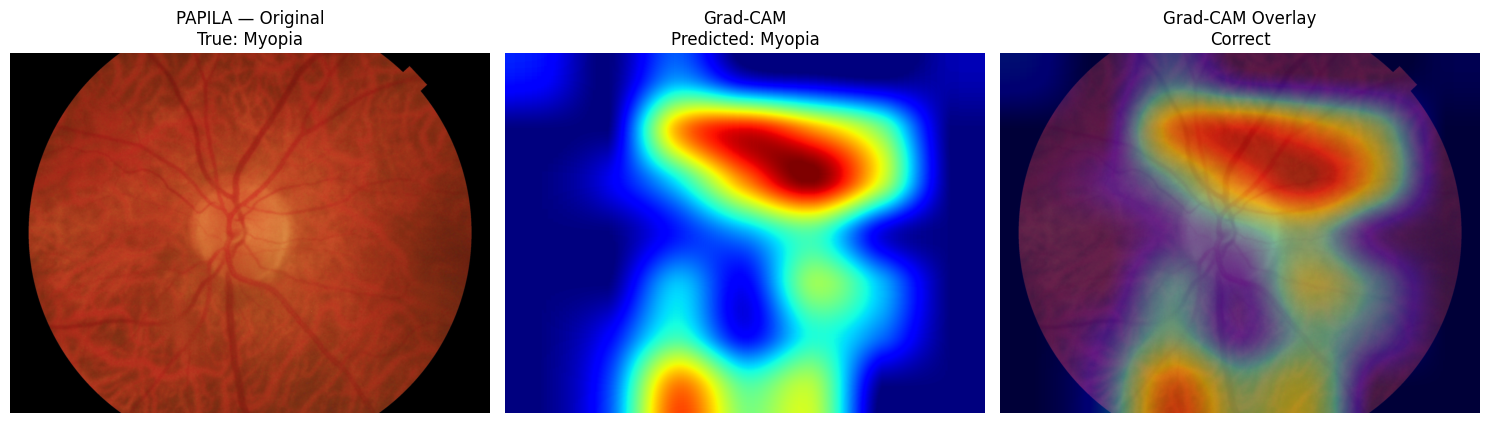

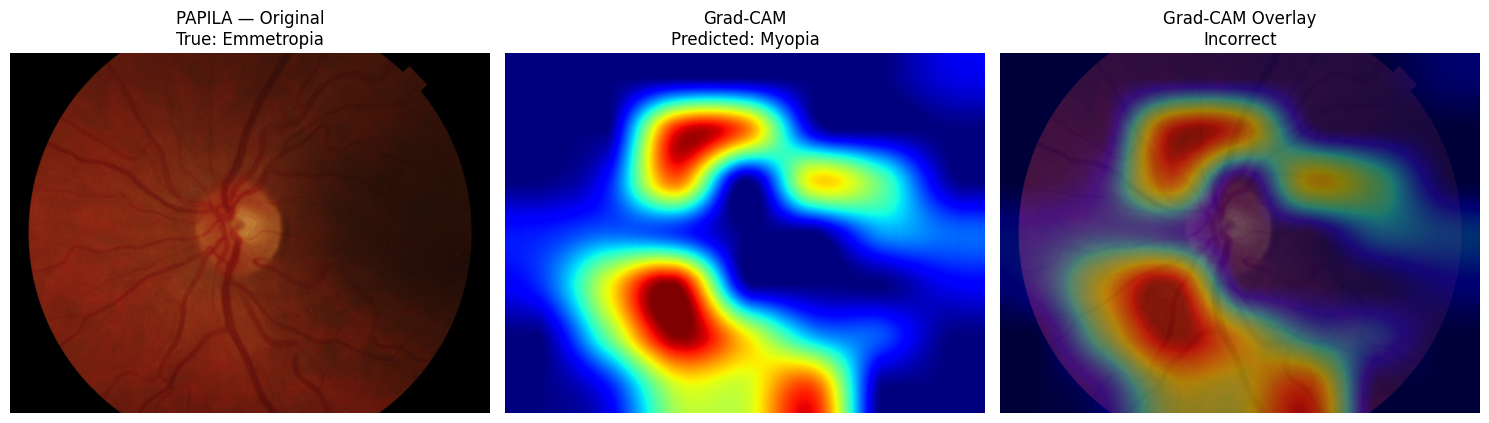

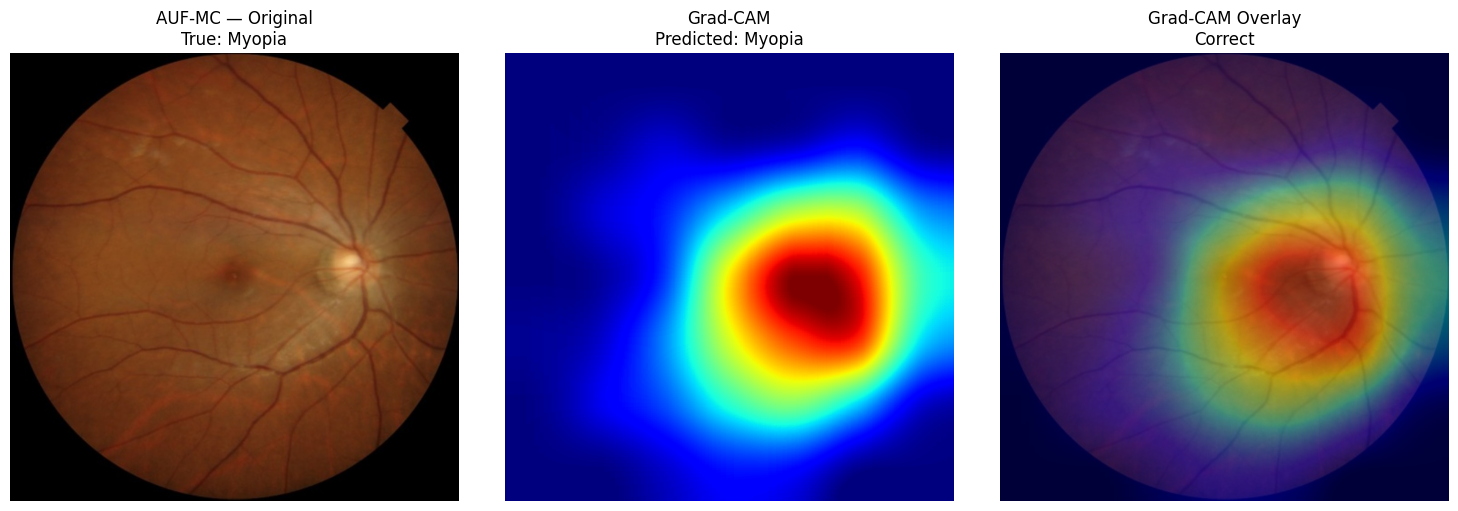

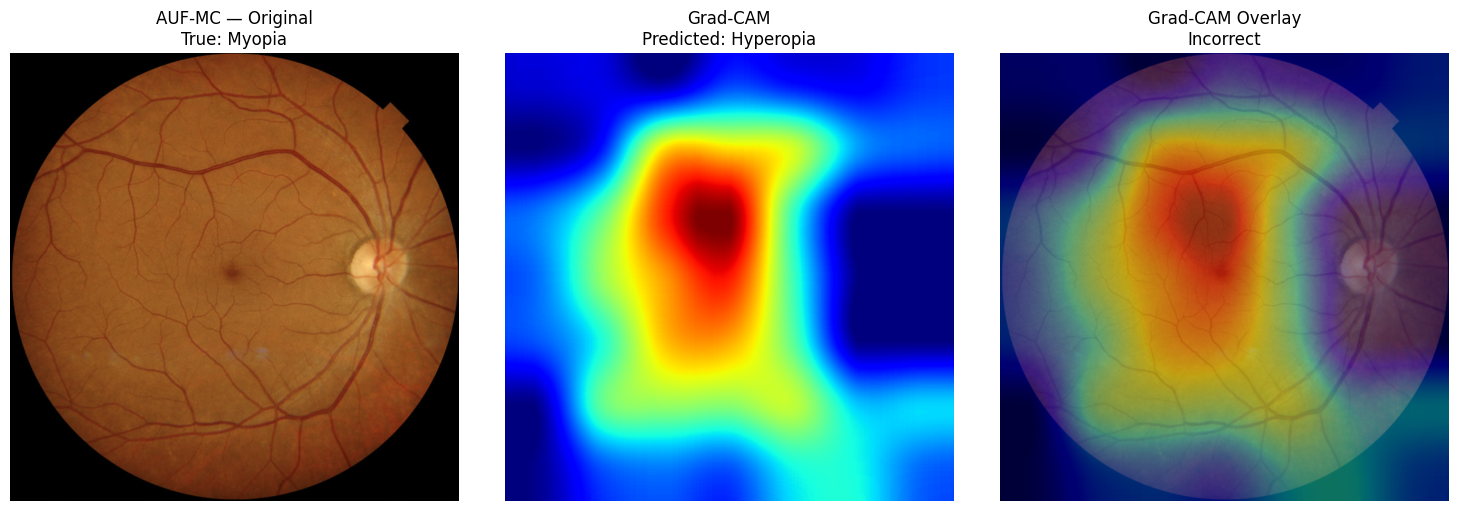

In [8]:
# =============================================================================
# SIMPLE PAPILA vs AUF-MC GRAD-CAM EVALUATION
# =============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

# -----------------------------------------------------------------------------
# 1. USE THE FINAL TRAINED RESNET50
# -----------------------------------------------------------------------------
model = final_model

# -----------------------------------------------------------------------------
# 2. USE THE HOLDOUT SET
# -----------------------------------------------------------------------------
gradcam_df = holdout_df.copy()

# -----------------------------------------------------------------------------
# 3. IMAGE SOURCE
# -----------------------------------------------------------------------------
gradcam_df["image_source"] = (
    gradcam_df["data_origin"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Normalize source names
gradcam_df["image_source"] = gradcam_df["image_source"].apply(
    lambda x:
        "PAPILA" if "PAPILA" in x
        else "AUF-MC" if "AUF" in x
        else "UNKNOWN"
)

# -----------------------------------------------------------------------------
# 4. CLASS LABELS
# -----------------------------------------------------------------------------
CLASS_NAMES = {
    0: "Emmetropia",
    1: "Myopia",
    2: "Hyperopia"
}

def get_label(value):

    if isinstance(value, (int, np.integer)):
        return int(value)

    value = str(value).strip().lower()

    mapping = {
        "emmetropia": 0,
        "myopia": 1,
        "hyperopia": 2,
        "0": 0,
        "1": 1,
        "2": 2
    }

    return mapping[value]


gradcam_df["true_label"] = (
    gradcam_df["classification"].apply(get_label)
)

# -----------------------------------------------------------------------------
# 5. FIND IMAGE PATH
# -----------------------------------------------------------------------------

if "full_path" in gradcam_df.columns:
    image_column = "full_path"

elif "image_path" in gradcam_df.columns:
    image_column = "image_path"

else:
    raise ValueError(
        "Could not find the image path column."
    )

# -----------------------------------------------------------------------------
# 6. IMAGE PREPROCESSING
# -----------------------------------------------------------------------------
IMAGE_SIZE = (224, 224)

def prepare_image(path):

    img = Image.open(path).convert("RGB")

    original = np.array(img)

    resized = img.resize(IMAGE_SIZE)

    array = np.array(resized).astype(np.float32)

    array = tf.keras.applications.resnet50.preprocess_input(
        array
    )

    return original, array

# -----------------------------------------------------------------------------
# 7. FIND LAST CONVOLUTIONAL LAYER
# -----------------------------------------------------------------------------
def find_last_conv_layer(model):

    for layer in reversed(model.layers):

        try:
            if len(layer.output.shape) == 4:
                return layer.name

        except:
            pass

    raise ValueError(
        "Could not find convolutional layer."
    )


LAST_CONV_LAYER_NAME = find_last_conv_layer(model)

print(
    "Grad-CAM layer:",
    LAST_CONV_LAYER_NAME
)

# -----------------------------------------------------------------------------
# 8. PREDICT ALL HOLDOUT IMAGES
# -----------------------------------------------------------------------------
predictions = []

for _, row in gradcam_df.iterrows():

    path = row[image_column]

    _, image_array = prepare_image(path)

    prediction = model.predict(
        np.expand_dims(image_array, axis=0),
        verbose=0
    )[0]

    predictions.append(
        np.argmax(prediction)
    )


gradcam_df["predicted_label"] = predictions

gradcam_df["prediction_status"] = np.where(
    gradcam_df["true_label"]
    ==
    gradcam_df["predicted_label"],
    "Correct",
    "Incorrect"
)

# =============================================================================
# 9. SIMPLE PAPILA vs AUF-MC RESULTS
# =============================================================================
print("\n")
print("=" * 60)
print("PAPILA vs AUF-MC PREDICTION RESULTS")
print("=" * 60)

source_results = (
    gradcam_df[
        gradcam_df["image_source"].isin(
            ["PAPILA", "AUF-MC"]
        )
    ]
    .groupby(
        ["image_source", "prediction_status"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

print(source_results)

# -----------------------------------------------------------------------------
# 10. PERCENTAGE OF CORRECT PREDICTIONS
# -----------------------------------------------------------------------------

for source in ["PAPILA", "AUF-MC"]:

    subset = gradcam_df[
        gradcam_df["image_source"] == source
    ]

    correct = (
        subset["prediction_status"] == "Correct"
    ).sum()

    total = len(subset)

    accuracy = (
        correct / total * 100
        if total > 0 else 0
    )

    print(
        f"{source}: "
        f"{correct}/{total} correct "
        f"({accuracy:.2f}%)"
    )

# =============================================================================
# 11. GRAD-CAM FUNCTION
# =============================================================================

def make_gradcam(
    image_array,
    model,
    layer_name,
    class_index
):

    grad_model = tf.keras.models.Model(
        model.inputs,
        [
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    image_tensor = tf.expand_dims(
        image_array,
        axis=0
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            image_tensor
        )

        class_output = predictions[:, class_index]

    gradients = tape.gradient(
        class_output,
        conv_outputs
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = (
        conv_outputs
        @ pooled_gradients[..., tf.newaxis]
    )

    heatmap = tf.squeeze(
        heatmap
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_value = tf.reduce_max(
        heatmap
    )

    if max_value > 0:
        heatmap /= max_value

    return heatmap.numpy()

# =============================================================================
# 12. SELECT REPRESENTATIVE IMAGES
# =============================================================================
selected = []

for source in ["PAPILA", "AUF-MC"]:

    for status in ["Correct", "Incorrect"]:

        candidates = gradcam_df[
            (gradcam_df["image_source"] == source)
            &
            (gradcam_df["prediction_status"] == status)
        ]

        if len(candidates) > 0:

            selected.append(
                candidates.sample(
                    n=1,
                    random_state=42
                ).iloc[0]
            )

# =============================================================================
# 13. DISPLAY GRAD-CAM RESULTS
# =============================================================================
print("\n")
print("=" * 60)
print("GRAD-CAM EXAMPLES")
print("=" * 60)

for row in selected:

    path = row[image_column]
    original, image_array = prepare_image(
        path
    )

    predicted_class = int(
        row["predicted_label"]
    )

# Generate Grad-CAM
    heatmap = make_gradcam(
        image_array,
        model,
        LAST_CONV_LAYER_NAME,
        predicted_class
    )

# Resize heatmap to original image dimensions
    heatmap_image = Image.fromarray(
        np.uint8(255 * heatmap)
    ).resize(
        (original.shape[1], original.shape[0])
    )

    heatmap_array = np.array(
        heatmap_image
    )

# -------------------------------------------------------------------------
# DISPLAY: ORIGINAL | GRAD-CAM | OVERLAY
# -------------------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

# 1. ORIGINAL IMAGE

    axes[0].imshow(original)

    axes[0].set_title(
        f"{row['image_source']} — Original\n"
        f"True: {CLASS_NAMES[row['true_label']]}"
    )

    axes[0].axis("off")

# 2. GRAD-CAM HEATMAP

    axes[1].imshow(
        heatmap_array,
        cmap="jet"
    )

    axes[1].set_title(
        f"Grad-CAM\n"
        f"Predicted: {CLASS_NAMES[predicted_class]}"
    )

    axes[1].axis("off")

 # 3. GRAD-CAM OVERLAY

    axes[2].imshow(original)

    axes[2].imshow(
        heatmap_array,
        cmap="jet",
        alpha=0.45
    )

    axes[2].set_title(
        f"Grad-CAM Overlay\n"
        f"{row['prediction_status']}"
    )

    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
# -----------------------------------------------------------------------------
# DEPLOYMENT EXPORT
# -----------------------------------------------------------------------------
# Save the trained final model and, when age is part of the selected
# configuration, its fitted scaler using the filenames expected by the app.
# Existing .pkl/.h5 artifacts are intentionally preserved in the repository.

import os
import shutil

MODEL_DIR = os.path.join(REPO_PATH, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

deployment_model_path = os.path.join(
    MODEL_DIR, f"best_{BEST_MODEL_NAME}_fold_1.keras"
)
shutil.copy2(
    f"/kaggle/working/{REPO_NAME}/artifacts/final_model.keras",
    deployment_model_path,
)

if USE_AGE:
    deployment_scaler_path = os.path.join(MODEL_DIR, "scaler_fold_1.joblib")
    shutil.copy2(
        f"/kaggle/working/{REPO_NAME}/artifacts/final_model_age_scaler.joblib",
        deployment_scaler_path,
    )
    print(f"Deployment scaler: {deployment_scaler_path}")

print(f"Deployment model: {deployment_model_path}")
print("Deployment export completed. Existing legacy .pkl/.h5 files were not removed.")

Deployment model: /kaggle/working/RefraScan/models/best_resnet50_fold_1.keras
Deployment export completed. Existing legacy .pkl/.h5 files were not removed.
